In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [5]:
# Load Data
mut_info_df = pd.read_csv('data/human.gencodeV44.pc_canonical.mut_info.tsv', sep='\t')
histone_anno = pd.read_csv("data/Human.gencodev44.histone.tsv", sep="\t")
rdh_ids = histone_anno[histone_anno["Type"] == "RDH"]["Geneid"].tolist()

Text(0.7873705226608188, 0.7892307692307692, '4-fold degenerate sites')

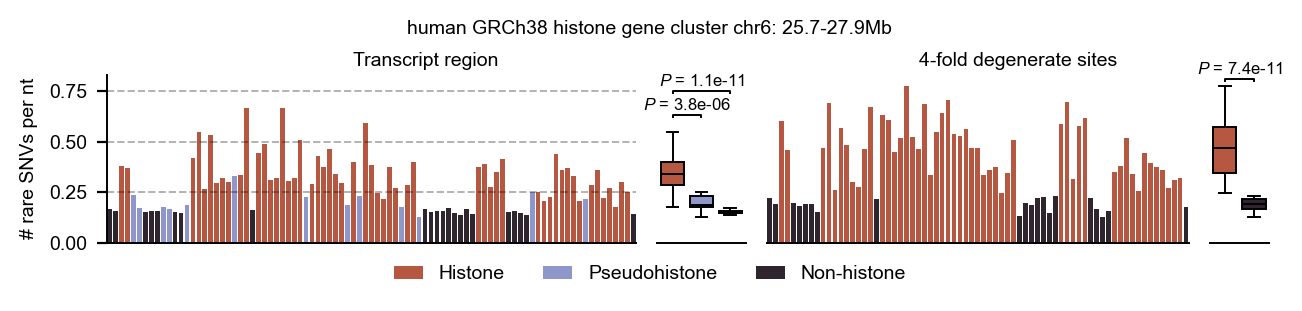

In [6]:
# Define filtering conditions
cluster_condition = (mut_info_df['chrom'] == 'chr6') & \
                    (mut_info_df['start'].between(25652000, 27920000))
allsite_condition = (mut_info_df['bigwig name'] == 'allsite_snv') & \
                    (mut_info_df['non-nan length'] > 50)
transcript_condition = (mut_info_df['region'] == 'transcript')
exclude_gene = (mut_info_df['gene id'] != 'ENSG00000282988.2')
pseudo_condition = (mut_info_df['gene type'] == 'protein_coding') | \
                   (mut_info_df['gene id'].isin(rdh_ids))

# Apply all filters in one step
transcript_filtered_df = mut_info_df.loc[
    cluster_condition & allsite_condition & transcript_condition & 
    exclude_gene & pseudo_condition
].copy()

# Add gene labels
transcript_filtered_df['gene label'] = 'other'
transcript_filtered_df.loc[transcript_filtered_df['gene id'].isin(rdh_ids), 'gene label'] = 'histone'
transcript_filtered_df.loc[transcript_filtered_df['gene type'] != 'protein_coding', 'gene label'] = 'pseudogene'

# Define filtering conditions
cluster_condition = (mut_info_df['chrom'] == 'chr6') & \
                    (mut_info_df['start'].between(25652000, 27920000))
allsite_condition = (mut_info_df['bigwig name'] == '4dsite_snv') & \
                    (mut_info_df['non-nan length'] > 50)
transcript_condition = (mut_info_df['region'] == 'CDS')
exclude_gene = (mut_info_df['gene id'] != 'ENSG00000282988.2')

# Apply all filters in one step
fdsite_filtered_df = mut_info_df.loc[
    cluster_condition & allsite_condition & transcript_condition & 
    exclude_gene
].copy()

# Add gene labels
fdsite_filtered_df['gene label'] = 'other'
fdsite_filtered_df.loc[fdsite_filtered_df['gene id'].isin(rdh_ids), 'gene label'] = 'histone'


fig, axes = plt.subplots(1, 4, figsize=(6.4, 1.3), width_ratios=(len(transcript_filtered_df), len(transcript_filtered_df) / 6, 
                                                               len(fdsite_filtered_df), len(transcript_filtered_df) / 9))
color_mapping = {
    'histone': '#CA4A2E', 
    'pseudogene': '#848FD4',  
    'other': '#302331' 
}

## Transcript
sns.barplot(
    transcript_filtered_df,
    x='gene name',
    y='mean value',
    hue='gene label',
    hue_order=['histone', 'pseudogene', 'other'],
    ax=axes[0],
    palette=color_mapping,
    width=0.8,
    # legend=False,
)

sns.boxplot(
    transcript_filtered_df,
    x='gene label',
    y='mean value',
    hue='gene label',
    ax=axes[1],
    order=['histone', 'pseudogene', 'other'],
    fliersize=1,
    linewidth=0.7,
    linecolor='black',
    palette=color_mapping,
    showfliers=False, 
)

## 4dsite
sns.barplot(
    fdsite_filtered_df,
    x='gene name',
    y='mean value',
    hue='gene label',
    hue_order=['histone', 'other'],
    ax=axes[2],
    width=0.8,
    # linewidth=0.5,
    # edgecolor='black',
    palette=color_mapping,
    legend=False,
)

sns.boxplot(
    fdsite_filtered_df,
    x='gene label',
    y='mean value',
    hue='gene label',
    ax=axes[3],
    order=['histone', 'other'],
    fliersize=1,
    linewidth=0.7,
    linecolor='black',
    palette=color_mapping,
)

ymax = 0.83
axes[0].set_xlabel('')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_xticklabels([])
axes[0].set_xticks([])
axes[0].set_ylim(0, ymax)

for idx, ax in enumerate(axes[1:]):
    ax.set_ylim(0, ymax)
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')

axes[0].set_ylabel('# rare SNVs per nt')
fig.suptitle("human GRCh38 histone gene cluster chr6: 25.7-27.9Mb", fontsize=7)
plt.tight_layout()

# Calculate p-value (transcript)
histone_values = transcript_filtered_df[transcript_filtered_df['gene label'] == 'histone']['mean value']
pseudogene_values = transcript_filtered_df[transcript_filtered_df['gene label'] == 'pseudogene']['mean value']
other_values = transcript_filtered_df[transcript_filtered_df['gene label'] == 'other']['mean value']
_, p_histone_pseudogene = mannwhitneyu(histone_values, pseudogene_values, alternative='two-sided')
_, p_histone_other = mannwhitneyu(histone_values, other_values, alternative='two-sided')

offset = 0.01
y1 = 0.63
y2 = 0.75
axes[1].plot([0, 0, 1, 1], [y1-offset, y1, y1, y1-offset], color='black', linewidth=0.7)
axes[1].plot([0, 0, 2, 2], [y2-offset, y2, y2, y2-offset], color='black', linewidth=0.7)

axes[1].text(0.5, y1+offset, rf'$P$ = {p_histone_pseudogene:.1e}', ha='center', va='bottom', fontsize=6)
axes[1].text(1, y2+offset, rf'$P$ = {p_histone_other:.1e}', ha='center', va='bottom', fontsize=6)

# Calculate p-value (4dsite)
histone_values_4d = fdsite_filtered_df[fdsite_filtered_df['gene label'] == 'histone']['mean value']
other_values_4d = fdsite_filtered_df[fdsite_filtered_df['gene label'] == 'other']['mean value']

y3 = 0.81
_, p_histone_other_4d = mannwhitneyu(histone_values_4d, other_values_4d, alternative='two-sided')
axes[3].plot([0, 0, 1, 1], [y3-offset, y3, y3, y3-offset], color='black', linewidth=0.7)
axes[3].text(0.5, y3+offset, rf'$P$ = {p_histone_other_4d:.1e}', ha='center', va='bottom', fontsize=6)

for ax in axes:
    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.7,
        alpha=0.3,
        color='black',
        zorder=-10
    )

# Add legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, [
        'Histone', 'Pseudohistone', 'Non-histone'
    ], loc='lower center', ncol=3, fontsize=7,
    bbox_to_anchor=(0.5, -0.1), frameon=False, handlelength=1.5
)
axes[0].legend_.remove()

# fig.supxlabel('Gene sort by TSS position on chromosome', fontsize=7, y=-0.05)
bbox0 = axes[0].get_position()
bbox1 = axes[1].get_position()
bbox2 = axes[2].get_position()
bbox3 = axes[3].get_position()

group1_center = (bbox0.x0 + bbox1.x1) / 2
group2_center = (bbox2.x0 + bbox3.x1) / 2
title_y = bbox0.y1 + 0.02

fig.text(
    group1_center, title_y, 'Transcript region', ha='center', va='bottom', fontsize=7
)
fig.text(
    group2_center, title_y, '4-fold degenerate sites', ha='center', va='bottom', fontsize=7
)